The objective of this notebook is to train a machine learning classifier to identify flooded and non-flooded regions using the latent features extracted by the convolutional autoencoder in Notebook 3. Instead of using raw SAR image pixels, we use the compressed feature representations learned by the encoder, which capture important flood-related patterns. A Random Forest classifier is trained on these features and evaluated using standard metrics such as accuracy, precision, recall, F1-score, and confusion matrix. The trained model is then saved for use in the prediction pipeline and web dashboard.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

In [3]:
FEATURE_DIR = "/content/drive/MyDrive/sar-project/data/features"
PROCESSED_DIR = "/content/drive/MyDrive/sar-project/data/processed"
MODEL_DIR = "/content/drive/MyDrive/sar-project/models"

os.makedirs(MODEL_DIR, exist_ok=True)

In [4]:
#LOAD FEATURES
X_train = np.load(
    os.path.join(FEATURE_DIR, "latent_features.npy"))
print("Feature Shape:", X_train.shape)

Feature Shape: (356, 16384)


In [5]:
#LOAD LABELS
y_train = np.load(
    os.path.join(PROCESSED_DIR, "y_train.npy"))
y_test = np.load(
    os.path.join(PROCESSED_DIR, "y_test.npy"))
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

y_train: (356,)
y_test : (90,)


In [6]:
#CHECK LABEL STRUCTURE
print("Unique values in y_train:")
print(np.unique(y_train))

Unique values in y_train:
[0 1]


In [7]:
#CONVERT MASKS TO SINGLE LABELS ,converting each mask into 1=flood present and 0=no flood
y_train_cls = np.array([
    1 if np.sum(mask) > 0 else 0
    for mask in y_train])
y_test_cls = np.array([
    1 if np.sum(mask) > 0 else 0
    for mask in y_test])
print("Training Labels:", np.unique(y_train_cls))
print("Testing Labels :", np.unique(y_test_cls))

Training Labels: [0 1]
Testing Labels : [0 1]


In [8]:
#SPLIT FEATURES
print(X_train.shape)
print(len(y_train_cls))

(356, 16384)
356


In [11]:
#LOAD ENCODER AND GENERATE TEST FEATURES
X_test = np.load(
    os.path.join(FEATURE_DIR, "latent_features.npy"))

In [12]:
#TRAIN RANDOM FOREST
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(
    X_train_rf,
    y_train_rf
)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [13]:
#PREDICTIONS
y_pred = rf_model.predict(X_test_rf)

In [14]:
#ACCURACY
accuracy = accuracy_score(
    y_test_rf,
    y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8750


In [16]:
#PRECISION,RECALL AND F1 SCORE
precision = precision_score(
    y_test_rf,
    y_pred)
recall = recall_score(
    y_test_rf,
    y_pred)
f1 = f1_score(
    y_test_rf,
    y_pred)
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
#CLASSIFICATION REPORT
print(
    classification_report(
        y_test_rf,
        y_pred   )
)

              precision    recall  f1-score   support

           0       0.88      1.00      0.93        63
           1       0.00      0.00      0.00         9

    accuracy                           0.88        72
   macro avg       0.44      0.50      0.47        72
weighted avg       0.77      0.88      0.82        72



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
#CONFUSION MATRIX
cm = confusion_matrix(
    y_test_rf,
    y_pred
)
print(cm)

[[63  0]
 [ 9  0]]


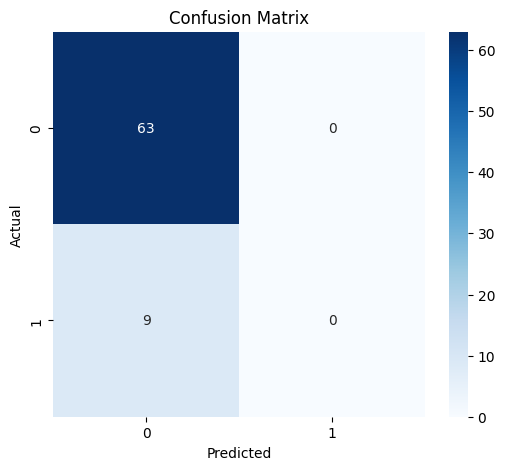

In [19]:
#PLOT CM
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [20]:
#FEATURE IMPORTANCE
importances = rf_model.feature_importances_
print("Number of Features:")
print(len(importances))

Number of Features:
16384


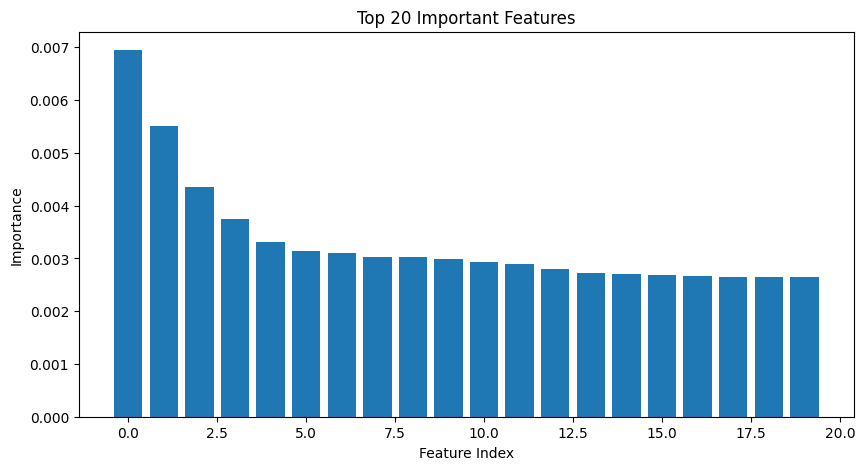

In [21]:
#TOP 20 FEATURES
indices = np.argsort(importances)[::-1][:20]
plt.figure(figsize=(10,5))
plt.bar(
    range(20),
    importances[indices])
plt.title("Top 20 Important Features")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

In [22]:
#SAVING TRAINED MODEL
joblib.dump(
    rf_model,
    os.path.join(
        MODEL_DIR,
        "random_forest_flood_classifier.pkl"
    ))
print("Model Saved Successfully")

Model Saved Successfully


In [23]:
print(os.listdir(MODEL_DIR))

['random_forest_flood_classifier.pkl']
